In this notebook, we try to find the best pretrained backbone for the jaguar reidentification. We try multiple backbones for embedding the jaguar images. After embedding we use a newly trained models using ArcFaceLoss. We compare the identity-based mAP for the validation set, the number of parameters and the training time. The notebooks compares the following backbones:
1. Megadescriptor
2. CLIP
3. DINOv3
4. EfficientNet
5. ResNet18

## 1. Setup and Configuration

In [1]:
EXPERIMENT_NAME = "backbone"
RANDOM_SEED = 51

import os

os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

from pathlib import Path
import sys

PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

from dotenv import load_dotenv
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image
from tabulate import tabulate
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from src.utils import (
    get_device,
    set_seeds,
    create_deterministic_training_dataloader,
)
from src.visualization import visualize_embeddings_mds

set_seeds(RANDOM_SEED)

print(f"PyTorch version: {torch.__version__}")

All random seeds set to 51 for reproducibility
PyTorch version: 2.9.1+cu128


In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

In [3]:
# Configuration
config = {   
    # MegaDescriptor Model
    "megadescriptor_model": "hf-hub:BVRA/MegaDescriptor-L-384",
    "megadescriptor_input_size": 384,
    
    # Clip Model
    "clip_model": "hf-hub:timm/vit_base_patch16_clip_224.openai",
    "clip_input_size": 224,
    
    # Dinov3 Model
    "dinov3_model": "hf-hub:timm/vit_base_patch16_dinov3.lvd1689m",
    "dinov3_input_size": 224,
    
    # EfficientNet Model
    "efficientnet_model": "hf-hub:timm/efficientnet_b0.ra_in1k",
    "efficientnet_input_size": 384,

    # ResNet18 Model
    "resnet18_model": "hf-hub:timm/resnet18.a1_in1k",
    "resnet18_input_size": 224,

    # ArcFace Model
    "embedding_dim": 256,
    "hidden_dim": 512,
    
    # ArcFace
    "arcface_margin": 0.5,
    "arcface_scale": 64.0,
    "dropout": 0.3,
    
    # Training
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 200,
    "patience": 10,
    "val_split": 0.2,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  megadescriptor_model: hf-hub:BVRA/MegaDescriptor-L-384
  megadescriptor_input_size: 384
  clip_model: hf-hub:timm/vit_base_patch16_clip_224.openai
  clip_input_size: 224
  dinov3_model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
  dinov3_input_size: 224
  efficientnet_model: hf-hub:timm/efficientnet_b0.ra_in1k
  efficientnet_input_size: 384
  resnet18_model: hf-hub:timm/resnet18.a1_in1k
  resnet18_input_size: 224
  embedding_dim: 256
  hidden_dim: 512
  arcface_margin: 0.5
  arcface_scale: 64.0
  dropout: 0.3
  batch_size: 32
  learning_rate: 0.0001
  weight_decay: 0.0001
  num_epochs: 200
  patience: 10
  val_split: 0.2
  seed: 51


In [4]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project="jaguar-reidentification",
        config=config,
        name=EXPERIMENT_NAME,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Loading

In [5]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv").set_index("filename")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


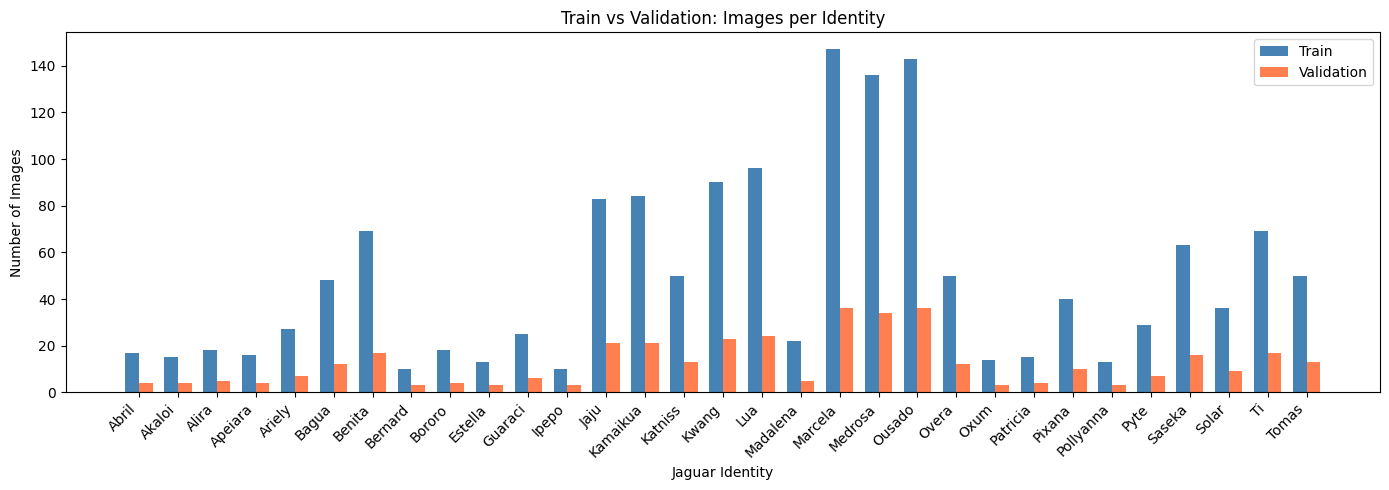


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [6]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Training Utils

In [7]:
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU
Using device: cuda


In [8]:
filenames = train_df.index.astype(str)
train_mask = filenames.isin(train_data.index.astype(str))

filenames = filenames.to_numpy()
labels = train_df["label_encoded"].to_numpy()
image_paths = [DATA_PATH / "train" / fn for fn in filenames]

In [9]:
@torch.no_grad()
def extract_embeddings(model, data_loader, desc="Extracting embeddings"):
    """Extract embeddings for a batch of images."""
    model.eval()
    embeddings = []

    for batch in tqdm(data_loader, desc=desc):
        batch = batch.to(device)
        with torch.no_grad():
            emb = model(batch)
        embeddings.append(emb.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

print("Embedding extraction function defined")

Embedding extraction function defined


In [10]:
# Extract baseline embeddings for training data

def _load_cached_embeddings(cache_path, expected_filenames):
    z = np.load(cache_path, allow_pickle=True)
    cached_embeddings = z["embeddings"]
    cached_filenames = z["filenames"].tolist() if isinstance(z["filenames"], np.ndarray) else list(z["filenames"])

    if len(cached_filenames) != len(expected_filenames):
        return None

    if set(cached_filenames) != set(expected_filenames):
        return None

    idx = {fn: i for i, fn in enumerate(cached_filenames)}
    return np.stack([cached_embeddings[idx[fn]] for fn in expected_filenames], axis=0)

def get_embeddings(model, cache_path, data_loader):
    embeddings = None
    if cache_path.exists():
        embeddings = _load_cached_embeddings(cache_path, filenames)
        if embeddings is not None:
            print(f"Loaded cached embeddings from {cache_path}")
            print(f"Embeddings shape: {embeddings.shape}")
            
    if embeddings is None:
        print(f"Extracting embeddings for {len(data_loader)} images...")
        embeddings = extract_embeddings(
            model,
            data_loader
        )
        np.savez_compressed(
            cache_path,
            embeddings=embeddings,
            filenames=np.array(filenames, dtype=object),
        )
        print(f"Saved embeddings cache to {cache_path}")
        print(f"Embeddings shape: {embeddings.shape}")
        
    return embeddings


In [11]:
train_labels = train_data.loc[filenames[train_mask], "label_encoded"].values
val_labels = val_data.loc[filenames[~train_mask], "label_encoded"].values

In [12]:
class EmbeddingProjection(nn.Module):
    """
    Projects MegaDescriptor embeddings to a lower-dimensional space.
    Architecture: input_dim -> hidden_dim -> output_dim
    """
    
    def __init__(self, input_dim=1536, hidden_dim=512, output_dim=256, dropout=0.3):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        return self.network(x)


class ArcFaceLayer(nn.Module):
    """
    ArcFace (Additive Angular Margin Loss) layer.
    
    The loss is computed as:
        L = -log(exp(s * cos(theta_y + m)) / (exp(s * cos(theta_y + m)) + sum(exp(s * cos(theta_j)))))
    
    where:
        - theta_y is the angle between embedding and ground truth class center
        - m is the angular margin (default 0.5 radians, about 28.6 degrees)
        - s is the feature scale (default 64)
    """
    
    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale
        
        # Learnable weight matrix (class prototypes on the hypersphere)
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        
        # Pre-compute trigonometric values for efficiency
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)  # Threshold for numerical stability
        self.mm = math.sin(math.pi - margin) * margin
    
    def forward(self, embeddings, labels):
        """
        Args:
            embeddings: (batch_size, embedding_dim) - will be normalized
            labels: (batch_size,) - ground truth class indices
        
        Returns:
            logits: (batch_size, num_classes) - ArcFace logits for cross-entropy loss
        """
        # Normalize embeddings and weights to unit length
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)
        
        # Compute cosine similarity: cos(theta)
        cosine = F.linear(embeddings, weight_norm)
        cosine = cosine.clamp(-1.0, 1.0)
        
        # Compute sin(theta) from cos(theta)
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        
        # Compute cos(theta + m) using angle addition formula
        # cos(theta + m) = cos(theta)*cos(m) - sin(theta)*sin(m)
        phi = cosine * self.cos_m - sine * self.sin_m
        
        # Apply threshold to handle theta + m >= pi
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        
        # One-hot encode labels
        one_hot = torch.zeros(cosine.size(), device=embeddings.device)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)
        
        # Apply margin only to ground truth class
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        
        # Scale logits
        output = output * self.scale
        
        return output


print("EmbeddingProjection and ArcFaceLayer defined")

EmbeddingProjection and ArcFaceLayer defined


In [13]:
class ImageDataset(Dataset):
    """PyTorch Dataset for images."""
    
    def __init__(self, filepaths, preprocess):
        self.filepaths = filepaths
        self.preprocess = preprocess

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert("RGB")
        return self.preprocess(image)

In [14]:
class EmbeddingDataset(Dataset):
    """PyTorch Dataset for pre-computed embeddings."""
    
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels = torch.LongTensor(labels)
        
        assert len(self.embeddings) == len(self.labels), "Embeddings and labels must have the same length"
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

In [15]:
class ArcFaceModel(nn.Module):
    """Complete model: Embedding Projection + ArcFace."""
    
    def __init__(self, input_dim, num_classes, embedding_dim=256, hidden_dim=512, margin=0.5, scale=64.0, dropout=0.3):
        super().__init__()
        self.embedding_net = EmbeddingProjection(
            input_dim=input_dim, 
            hidden_dim=hidden_dim,
            output_dim=embedding_dim,
            dropout=dropout
        )
        self.arcface = ArcFaceLayer(
            embedding_dim=embedding_dim, 
            num_classes=num_classes,
            margin=margin, 
            scale=scale
        )
    
    def forward(self, x, labels):
        """Forward pass for training (requires labels for ArcFace)."""
        embeddings = self.embedding_net(x)
        logits = self.arcface(embeddings, labels)
        return logits, embeddings
    
    def get_embeddings(self, x):
        """Get normalized embeddings for inference."""
        embeddings = self.embedding_net(x)
        return F.normalize(embeddings, p=2, dim=1)

print(f"ArcFace Model:")
print(f"  Hidden dim: {config['hidden_dim']}")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Dropout: {config['dropout']}")
print(f"  Num classes: {num_classes}")
print(f"  ArcFace margin: {config['arcface_margin']}")

print(f"  ArcFace scale: {config['arcface_scale']}")

ArcFace Model:
  Hidden dim: 512
  Embedding dim: 256
  Dropout: 0.3
  Num classes: 31
  ArcFace margin: 0.5
  ArcFace scale: 64.0


In [16]:
def compute_validation_map(model, val_loader):
    """
    Compute identity-balanced mean Average Precision on validation set.
    
    This simulates the competition metric:
    1. For each query, rank all other images by cosine similarity
    2. Compute Average Precision based on where true matches appear
    3. Average APs within each identity, then average across identities
    """
    model.eval()
    
    val_embeddings = []
    val_labels = []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            embeddings = model.get_embeddings(images)
            val_embeddings.append(embeddings.cpu().numpy())
            val_labels.append(labels.cpu().numpy())

    val_embeddings = np.concatenate(val_embeddings)
    val_labels = np.concatenate(val_labels)

    # Compute cosine similarity matrix
    sim_matrix = cosine_similarity(val_embeddings)
    np.fill_diagonal(sim_matrix, -1)  # Exclude self-similarity

    # Compute AP for each query
    query_aps = {}
    
    for query_idx in range(len(val_labels)):
        query_label = val_labels[query_idx]
        
        # Get similarities to all gallery images (excluding self)
        similarities = sim_matrix[query_idx]
        
        # True labels for gallery
        gallery_labels = val_labels.copy()
        is_match = (gallery_labels == query_label).astype(int)
        is_match[query_idx] = 0  # Exclude self
        
        # Sort by similarity descending
        sorted_indices = np.argsort(-similarities)
        sorted_matches = is_match[sorted_indices]
        
        # Compute Average Precision
        n_positives = sorted_matches.sum()
        if n_positives == 0:
            continue
        
        cumsum = np.cumsum(sorted_matches)
        precision_at_k = cumsum / np.arange(1, len(sorted_matches) + 1)
        ap = np.sum(precision_at_k * sorted_matches) / n_positives
        
        query_aps[query_idx] = (query_label, ap)
    
    # Group by identity and compute identity-balanced mAP
    identity_aps = {}
    for query_idx, (label, ap) in query_aps.items():
        if label not in identity_aps:
            identity_aps[label] = []
        identity_aps[label].append(ap)
    
    # Average within identity, then across identities
    identity_mean_aps = [np.mean(aps) for aps in identity_aps.values()]
    balanced_map = np.mean(identity_mean_aps)
    
    return balanced_map


print("Validation mAP function defined")

Validation mAP function defined


In [17]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training', leave=False)
    for embeddings, labels in pbar:
        embeddings, labels = embeddings.to(device), labels.to(device)
        
        # Forward pass
        logits, _ = model(embeddings, labels)
        loss = criterion(logits, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Metrics
        total_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.1f}%'})
    
    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


def validate_epoch(model, loader, criterion, device):
    """Validate for one epoch."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation', leave=False)
        for embeddings, labels in pbar:
            embeddings, labels = embeddings.to(device), labels.to(device)
            
            logits, _ = model(embeddings, labels)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.1f}%'})
    
    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


print("Training and validation functions defined")

Training and validation functions defined


In [18]:
def train(model, train_loader, val_loader, criterion, optimizer, scheduler, device, name):
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'val_map': [], 'lr': []
    }

    best_val_loss = float('inf')
    best_map = 0.0
    patience_counter = 0
    best_epoch = 0

    print(f"Starting training for {config['num_epochs']} epochs...")
    print("=" * 70)

    for epoch in range(config['num_epochs']):
        print(f"\nEpoch {epoch+1}/{config['num_epochs']}")
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
        
        # Compute validation mAP
        val_map = compute_validation_map(
            model, 
            val_loader,
        )
        
        # Update scheduler
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_map'].append(val_map)
        history['lr'].append(current_lr)
        
        # Log to W&B
        wandb.log({
            'model': name,
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_map': val_map,
            'learning_rate': current_lr,
        })
        
        # Print summary
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.1f}%")
        print(f"  Val mAP:    {val_map:.4f} | LR: {current_lr:.2e}")
        
        # Checkpoint best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_map = val_map
            best_epoch = epoch + 1
            patience_counter = 0

            checkpoint_path = CHECKPOINT_PATH / f"arcface_best_{name}.pth"
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_map': val_map,
                'config': config,
                'label_encoder_classes': label_encoder.classes_.tolist(),
                'num_classes': num_classes,
                'name': name
            }, checkpoint_path)
            
            print(f"  [New best model saved]")
        else:
            patience_counter += 1
            print(f"  No improvement. Patience: {patience_counter}/{config['patience']}")
        
        # Early stopping
        if patience_counter >= config['patience']:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

    print("\n" + "=" * 70)
    print(f"Training complete!")
    print(f"Best epoch: {best_epoch} (Val Loss: {best_val_loss:.4f}, Val mAP: {best_map:.4f})")
    
    return history, best_val_loss, best_map, best_epoch

print("Train function defined")

Train function defined


In [19]:
def plot_history(history, best_epoch):
    # Plot training curves
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    epochs_range = range(1, len(history['train_loss']) + 1)

    # Loss
    axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
    axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Validation')
    axes[0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_epoch})')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train')
    axes[1].plot(epochs_range, history['val_acc'], 'r-', label='Validation')
    axes[1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # mAP
    axes[2].plot(epochs_range, history['val_map'], 'purple', linewidth=2)
    axes[2].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('mAP')
    axes[2].set_title('Validation mAP (Identity-Balanced)')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    
    return fig


In [20]:
table = [
    ["Backbone", "Best val_loss", "Best val_mAP", "Best epoch", "Num params", "Embedding Time", "Training Time"]
]

## Megadescriptor

In [21]:
# Load MegaDescriptor model
print("Loading MegaDescriptor-L-384 model...")
megadescriptor = timm.create_model(
    config["megadescriptor_model"],
    pretrained=True
)
megadescriptor.eval()
megadescriptor.to(device)
megadescriptor.compile()

megadescriptor_config = resolve_data_config({}, model=megadescriptor)
megadescriptor_preprocess = create_transform(**megadescriptor_config, is_training=False)

megadescriptor_num_params = sum(p.numel() for p in megadescriptor.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {megadescriptor_num_params:,}")
print(f"  Preprocessing: {megadescriptor_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = megadescriptor_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = megadescriptor(dummy_input)
    megadescriptor_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {megadescriptor_dim}")

Loading MegaDescriptor-L-384 model...
Model loaded successfully
  Parameters: 195,198,516
  Preprocessing: {'input_size': [3, 384, 384], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 0.9, 'crop_mode': 'center'}
  Embedding dimension: 1536


In [22]:
megadescriptor_dataset = ImageDataset(image_paths, megadescriptor_preprocess)
megadescriptor_loader = DataLoader(
    megadescriptor_dataset,
    batch_size=config["batch_size"],
    num_workers=2,
    shuffle=False
)

print(f"MegaDescriptor DataLoader created with {len(megadescriptor_loader)} batches")

MegaDescriptor DataLoader created with 60 batches


In [23]:
megadescriptor_cache_path = EMBEDDINGS_PATH / "megadescriptor_embeddings.npz"

megadescriptor_embeddings = get_embeddings(
    megadescriptor,
    megadescriptor_cache_path,
    megadescriptor_loader
)

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/backbone/embeddings/megadescriptor_embeddings.npz
Embeddings shape: (1895, 1536)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


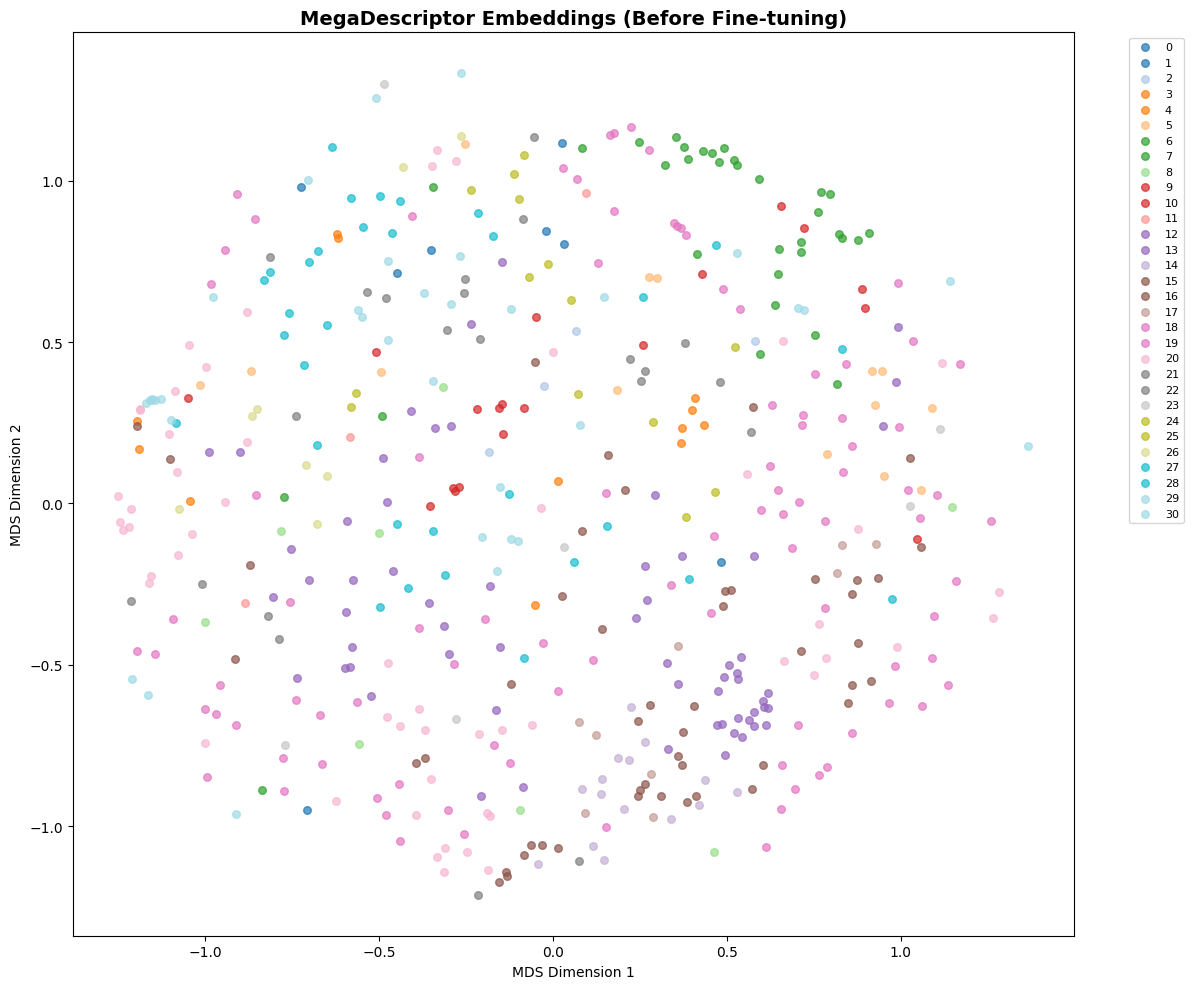

In [24]:
# Visualize MegaDescriptor embeddings
labels = np.array(labels)
fig = visualize_embeddings_mds(
    megadescriptor_embeddings,
    labels,
    "MegaDescriptor Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "megadescriptor_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"megadescriptor_embeddings_mds": wandb.Image(fig)})

In [25]:
megadescriptor_emb_train_dataset = EmbeddingDataset(
    megadescriptor_embeddings[train_mask],
    train_labels
)

megadescriptor_emb_val_dataset = EmbeddingDataset(
    megadescriptor_embeddings[~train_mask],
    val_labels
)

megadescriptor_emb_train_loader = create_deterministic_training_dataloader(
    megadescriptor_emb_train_dataset,
    batch_size=config["batch_size"],
)
megadescriptor_emb_val_loader = DataLoader(
    megadescriptor_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=2,
    shuffle=False
)

In [26]:
# Create model
model = ArcFaceModel(
    input_dim=megadescriptor_dim,
    num_classes=num_classes,
    embedding_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    margin=config["arcface_margin"],
    dropout=config["dropout"],
).to(device)

model_num_params = sum(p.numel() for p in model.parameters())

print(f"  Total parameters: {model_num_params:,}")

  Total parameters: 927,744


In [27]:
# Setup training components
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: CrossEntropyLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [28]:
# Training loop
set_seeds(config['seed'])
history, best_val_loss, best_map_duplicated, best_epoch = train(
    model, 
    megadescriptor_emb_train_loader, 
    megadescriptor_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="megadescriptor"
)

wandb.log({
    "final_val_loss_megadescriptor": best_val_loss,
    "final_val_mAP_megadescriptor": best_map_duplicated,
    "best_epoch_megadescriptor": best_epoch,
    "total_epochs_megadescriptor": len(history['train_loss']),
})

table.append([
    "MegaDescriptor",
    best_val_loss,
    best_map_duplicated,
    best_epoch,
    megadescriptor_num_params,
    model_num_params,
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 36.2975 | Train Acc: 0.0%
  Val Loss:   32.3945 | Val Acc:   0.0%
  Val mAP:    0.2921 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 31.6302 | Train Acc: 0.1%
  Val Loss:   28.3017 | Val Acc:   1.8%
  Val mAP:    0.3106 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 28.4562 | Train Acc: 0.6%
  Val Loss:   25.4216 | Val Acc:   7.1%
  Val mAP:    0.3305 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 25.5204 | Train Acc: 2.5%
  Val Loss:   22.7260 | Val Acc:   9.2%
  Val mAP:    0.3560 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.1989 | Train Acc: 95.1%
  Val Loss:   4.6012 | Val Acc:   83.4%
  Val mAP:    0.7872 | LR: 2.50e-05
  No improvement. Patience: 6/10

Epoch 79/200


  Train Loss: 0.2485 | Train Acc: 93.5%
  Val Loss:   4.6264 | Val Acc:   84.4%
  Val mAP:    0.7864 | LR: 2.50e-05
  No improvement. Patience: 7/10

Epoch 80/200


  Train Loss: 0.1739 | Train Acc: 95.4%
  Val Loss:   4.6563 | Val Acc:   83.9%
  Val mAP:    0.7863 | LR: 2.50e-05
  No improvement. Patience: 8/10

Epoch 81/200


  Train Loss: 0.2174 | Train Acc: 95.3%
  Val Loss:   4.6605 | Val Acc:   83.9%
  Val mAP:    0.7870 | LR: 2.50e-05
  No improvement. Patience: 9/10

Epoch 82/200


  Train Loss: 0.1906 | Train Acc: 94.3%
  Val Loss:   4.6491 | Val Acc:   84.7%
  Val mAP:    0.7889 | LR: 2.50e-05
  No improvement. Patience: 10/10

Early stopping triggered after 82 epochs

Training complete!
Best epoch: 72 (Val Loss: 4.5936, Val mAP: 0.7879)


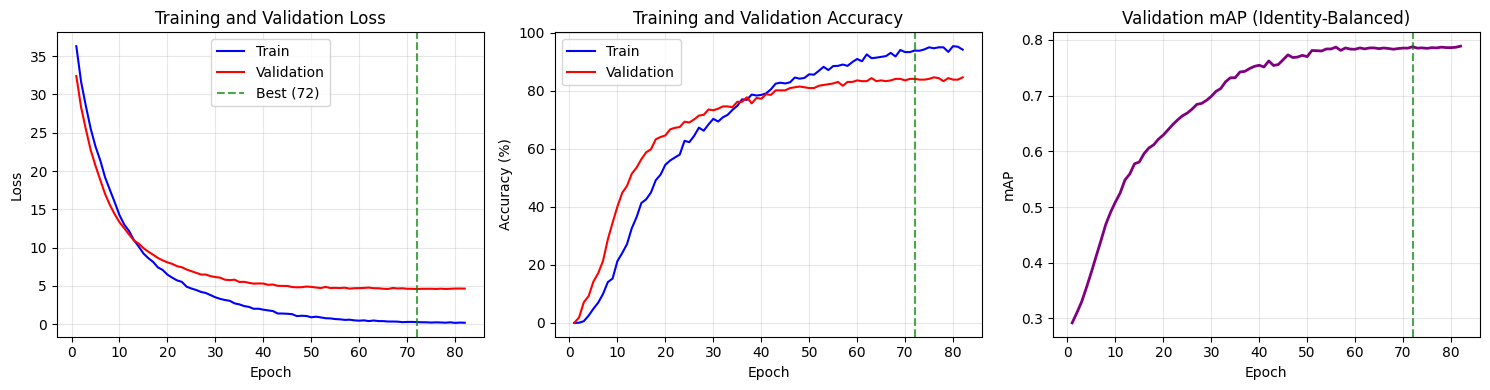

In [29]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_megadescriptor.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_megadescriptor": wandb.Image(fig)})

In [30]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "arcface_best_megadescriptor.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/backbone
  Val Loss: 4.5936
  Val mAP: 0.7879


In [31]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(megadescriptor_embeddings).to(device)
    finetuned_embeddings = model.get_embeddings(train_tensor).cpu().numpy()

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


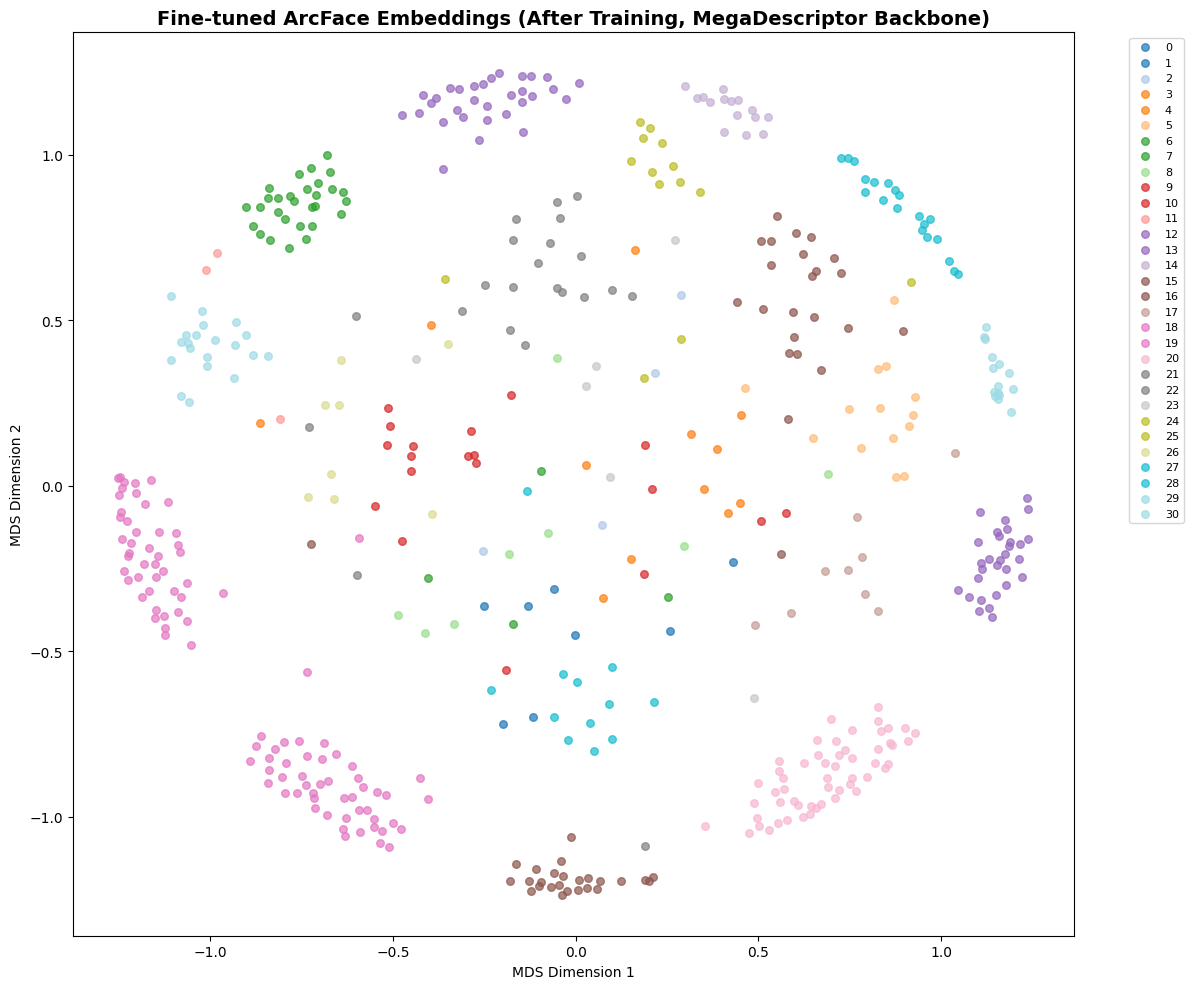

In [32]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ArcFace Embeddings (After Training, MegaDescriptor Backbone)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "megadescriptor_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_megadescriptor": wandb.Image(fig_finetuned)})

In [33]:
del megadescriptor_dataset, megadescriptor_loader, megadescriptor_emb_train_dataset, megadescriptor_emb_val_dataset
del model, optimizer, scheduler, history
del megadescriptor, megadescriptor_preprocess, megadescriptor_embeddings, finetuned_embeddings
torch.cuda.empty_cache()

## CLIP

In [34]:
# Load CLIP model
print("Loading CLIP model...")
clip = timm.create_model(
    config["clip_model"],
    pretrained=True
)
clip.eval()
clip.to(device)
clip.compile()

clip_config = resolve_data_config({}, model=clip)
clip_preprocess = create_transform(**clip_config, is_training=False)

clip_num_params = sum(p.numel() for p in clip.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {clip_num_params:,}")
print(f"  Preprocessing: {clip_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = clip_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = clip(dummy_input)
    clip_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {clip_dim}")

Loading CLIP model...
Model loaded successfully
  Parameters: 86,193,152
  Preprocessing: {'input_size': [3, 224, 224], 'interpolation': 'bicubic', 'mean': [0.48145466, 0.4578275, 0.40821073], 'std': [0.26862954, 0.26130258, 0.27577711], 'crop_pct': 0.9, 'crop_mode': 'center'}
  Embedding dimension: 512


In [35]:
clip_dataset = ImageDataset(image_paths, clip_preprocess)
clip_loader = DataLoader(
    clip_dataset,
    batch_size=config["batch_size"],
    num_workers=2,
    shuffle=False
)

print(f"CLIP DataLoader created with {len(clip_loader)} batches")

CLIP DataLoader created with 60 batches


In [36]:
clip_cache_path = EMBEDDINGS_PATH / "clip_embeddings.npz"

clip_embeddings = get_embeddings(
    clip,
    clip_cache_path,
    clip_loader
)

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/backbone/embeddings/clip_embeddings.npz
Embeddings shape: (1895, 512)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


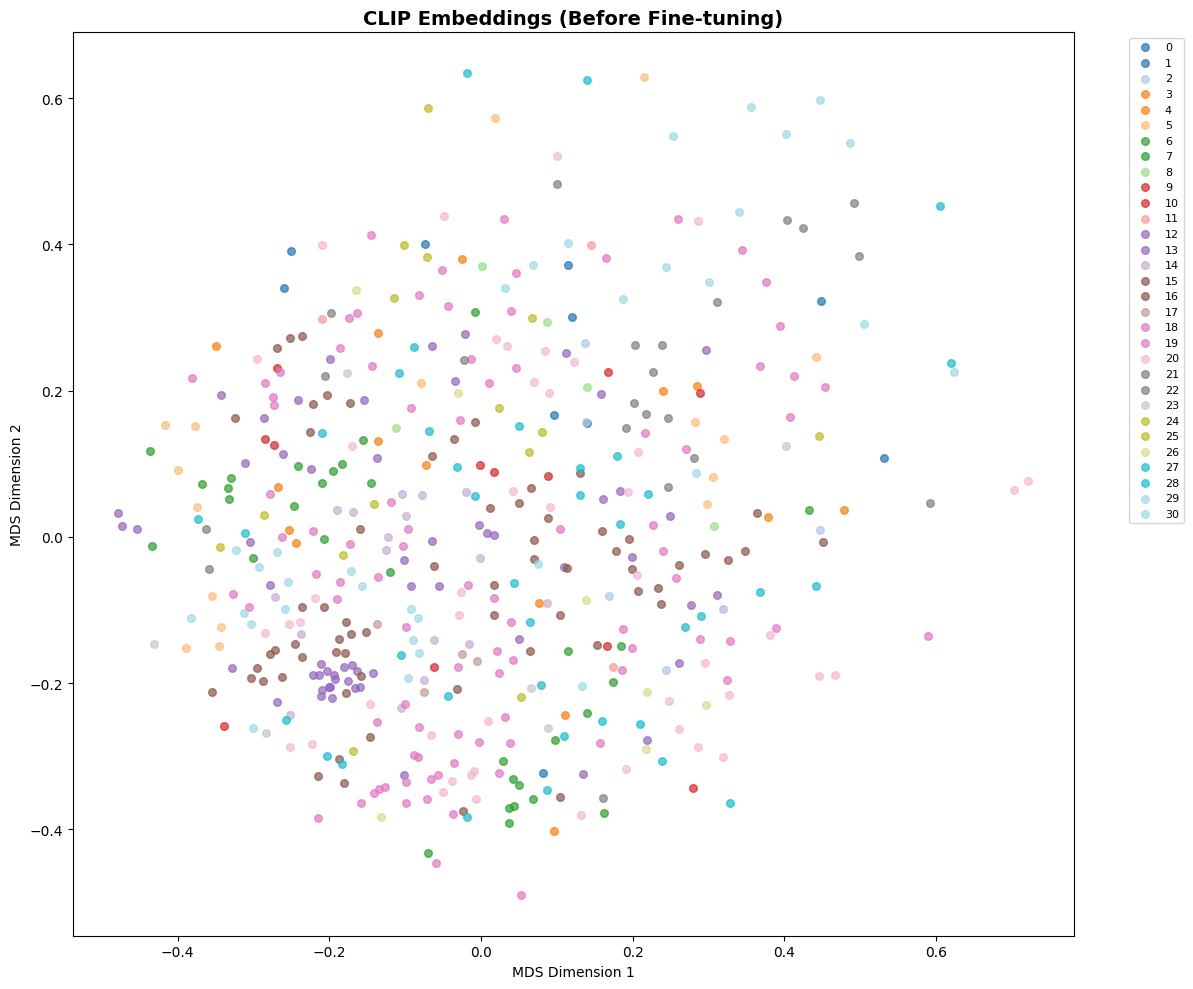

In [37]:
# Visualize CLIP embeddings
fig = visualize_embeddings_mds(
    clip_embeddings,
    labels,
    "CLIP Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "clip_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"clip_embeddings_mds": wandb.Image(fig)})

In [38]:
clip_emb_train_dataset = EmbeddingDataset(
    clip_embeddings[train_mask],
    train_labels
)

clip_emb_val_dataset = EmbeddingDataset(
    clip_embeddings[~train_mask],
    val_labels
)

clip_emb_train_loader = create_deterministic_training_dataloader(
    clip_emb_train_dataset,
    batch_size=config["batch_size"],
)
clip_emb_val_loader = DataLoader(
    clip_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=2,
    shuffle=False
)

In [39]:
# Create model
model = ArcFaceModel(
    input_dim=clip_dim,
    num_classes=num_classes,
    embedding_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    margin=config["arcface_margin"],
    dropout=config["dropout"],
).to(device)

model_num_params = sum(p.numel() for p in model.parameters())

print(f"  Total parameters: {model_num_params:,}")

  Total parameters: 403,456


In [40]:
# Setup training components
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: CrossEntropyLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [41]:
# Training loop
set_seeds(config['seed'])
history, best_val_loss, best_map, best_epoch = train(
    model, 
    clip_emb_train_loader, 
    clip_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="clip"
)

wandb.log({
    "final_val_loss_clip": best_val_loss,
    "final_val_mAP_clip": best_map_duplicated,
    "best_epoch_clip": best_epoch,
    "total_epochs_clip": len(history['train_loss']),
})

table.append([
    "CLIP",
    best_val_loss,
    best_map,
    best_epoch,
    clip_num_params,
    model_num_params,
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Validation:   0%|          | 0/12 [00:00<?, ?it/s]                                

  Train Loss: 37.5665 | Train Acc: 0.0%
  Val Loss:   34.6258 | Val Acc:   0.0%
  Val mAP:    0.2935 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 34.3436 | Train Acc: 0.0%
  Val Loss:   31.6747 | Val Acc:   0.0%
  Val mAP:    0.3033 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 31.9002 | Train Acc: 0.0%
  Val Loss:   29.3260 | Val Acc:   0.0%
  Val mAP:    0.3173 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 0.2709 | Train Acc: 94.1%
  Val Loss:   4.8004 | Val Acc:   77.8%
  Val mAP:    0.8209 | LR: 2.50e-05
  No improvement. Patience: 6/10

Epoch 142/200


  Train Loss: 0.2742 | Train Acc: 93.5%
  Val Loss:   4.7429 | Val Acc:   78.4%
  Val mAP:    0.8250 | LR: 2.50e-05
  No improvement. Patience: 7/10

Epoch 143/200


  Train Loss: 0.2291 | Train Acc: 95.0%
  Val Loss:   4.7619 | Val Acc:   77.6%
  Val mAP:    0.8253 | LR: 2.50e-05
  No improvement. Patience: 8/10

Epoch 144/200


  Train Loss: 0.1811 | Train Acc: 94.9%
  Val Loss:   4.8387 | Val Acc:   78.1%
  Val mAP:    0.8258 | LR: 2.50e-05
  No improvement. Patience: 9/10

Epoch 145/200


  Train Loss: 0.1912 | Train Acc: 94.6%
  Val Loss:   4.7825 | Val Acc:   78.4%
  Val mAP:    0.8212 | LR: 2.50e-05
  No improvement. Patience: 10/10

Early stopping triggered after 145 epochs

Training complete!
Best epoch: 135 (Val Loss: 4.7109, Val mAP: 0.8261)


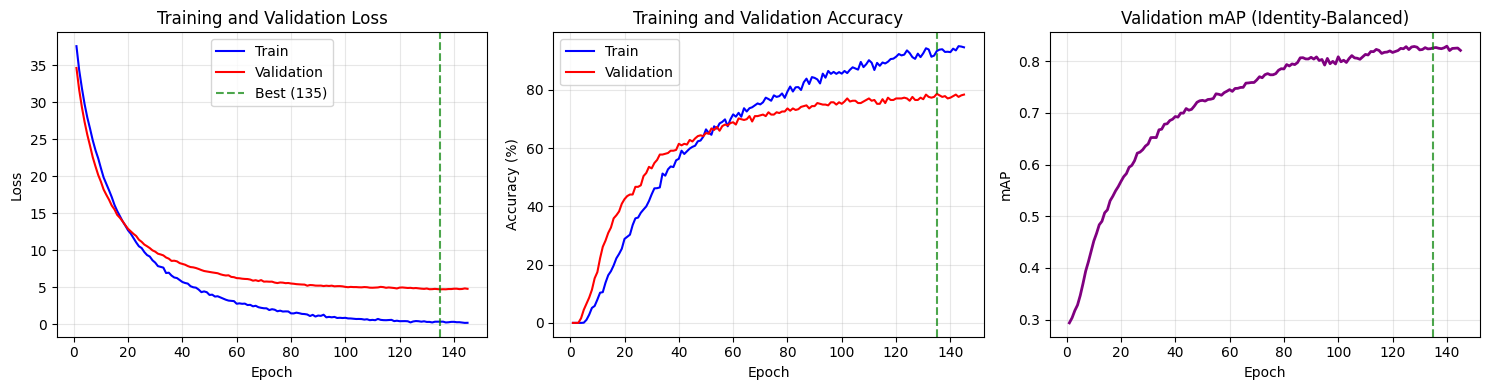

In [42]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_clip.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_clip": wandb.Image(fig)})

In [43]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "arcface_best_clip.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/backbone
  Val Loss: 4.7109
  Val mAP: 0.8261


In [44]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(clip_embeddings).to(device)
    finetuned_embeddings = model.get_embeddings(train_tensor).cpu().numpy()

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


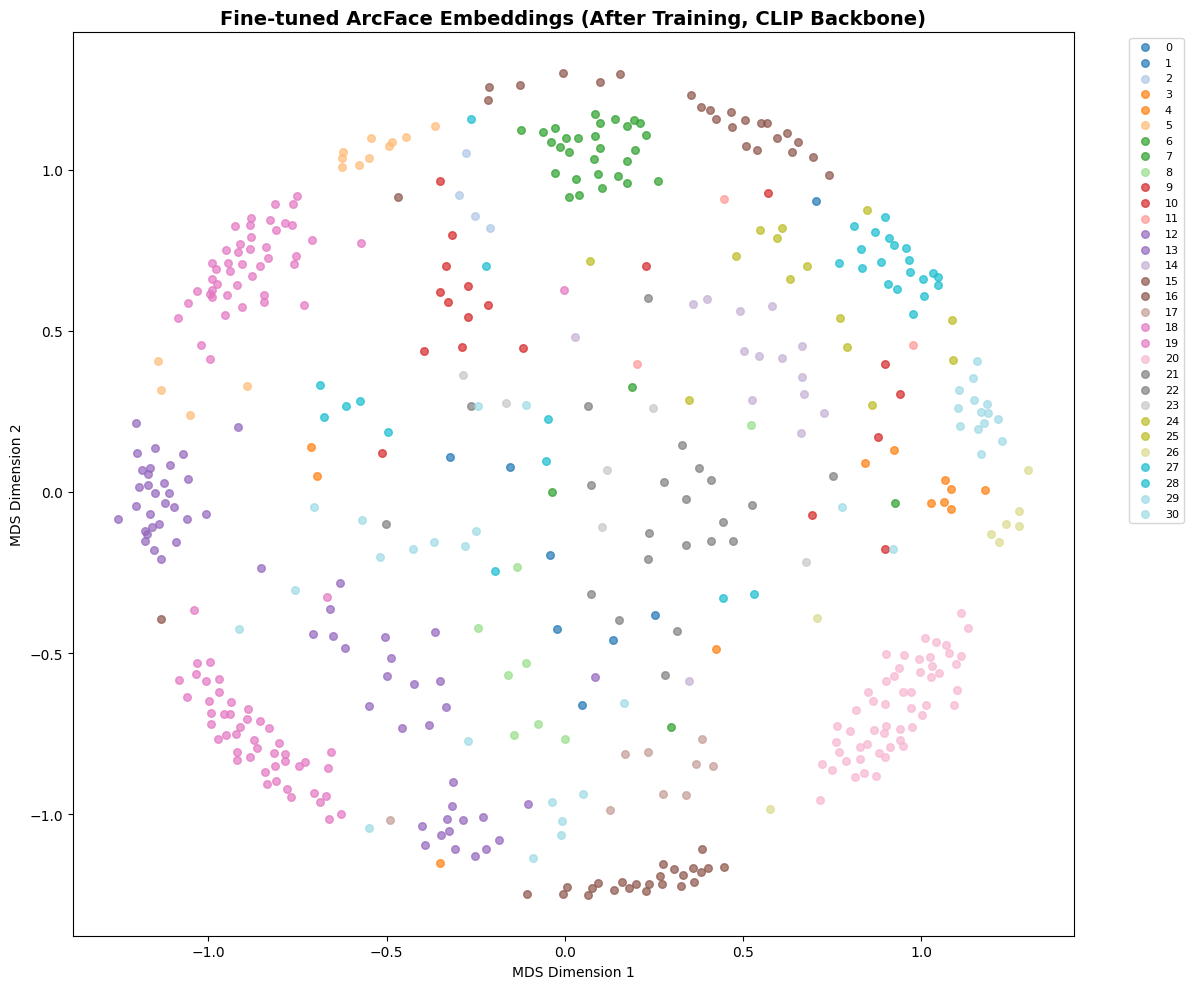

In [45]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ArcFace Embeddings (After Training, CLIP Backbone)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "clip_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_clip": wandb.Image(fig_finetuned)})

In [46]:
del clip_dataset, clip_loader, clip_emb_train_dataset, clip_emb_val_dataset
del model, optimizer, scheduler, history
del clip, clip_preprocess, clip_embeddings, finetuned_embeddings
torch.cuda.empty_cache()

## Dinov3

In [47]:
# Load Dino model
print("Loading Dino model...")
dino = timm.create_model(
    config["dinov3_model"],
    pretrained=True
)
dino.eval()
dino.to(device)
dino.compile()

dino_config = resolve_data_config({}, model=dino)
dino_preprocess = create_transform(**dino_config, is_training=False)

dino_num_params = sum(p.numel() for p in dino.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {dino_num_params:,}")
print(f"  Preprocessing: {dino_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = dino_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = dino(dummy_input)
    dino_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {dino_dim}")

Loading Dino model...
Model loaded successfully
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}
  Embedding dimension: 768


In [48]:
dino_dataset = ImageDataset(image_paths, dino_preprocess)
dino_loader = DataLoader(
    dino_dataset,
    batch_size=config["batch_size"],
    num_workers=2,
    shuffle=False
)

print(f"Dino DataLoader created with {len(dino_loader)} batches")

Dino DataLoader created with 60 batches


In [49]:
dino_cache_path = EMBEDDINGS_PATH / "dino_embeddings.npz"

dino_embeddings = get_embeddings(
    dino,
    dino_cache_path,
    dino_loader
)

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/backbone/embeddings/dino_embeddings.npz
Embeddings shape: (1895, 768)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


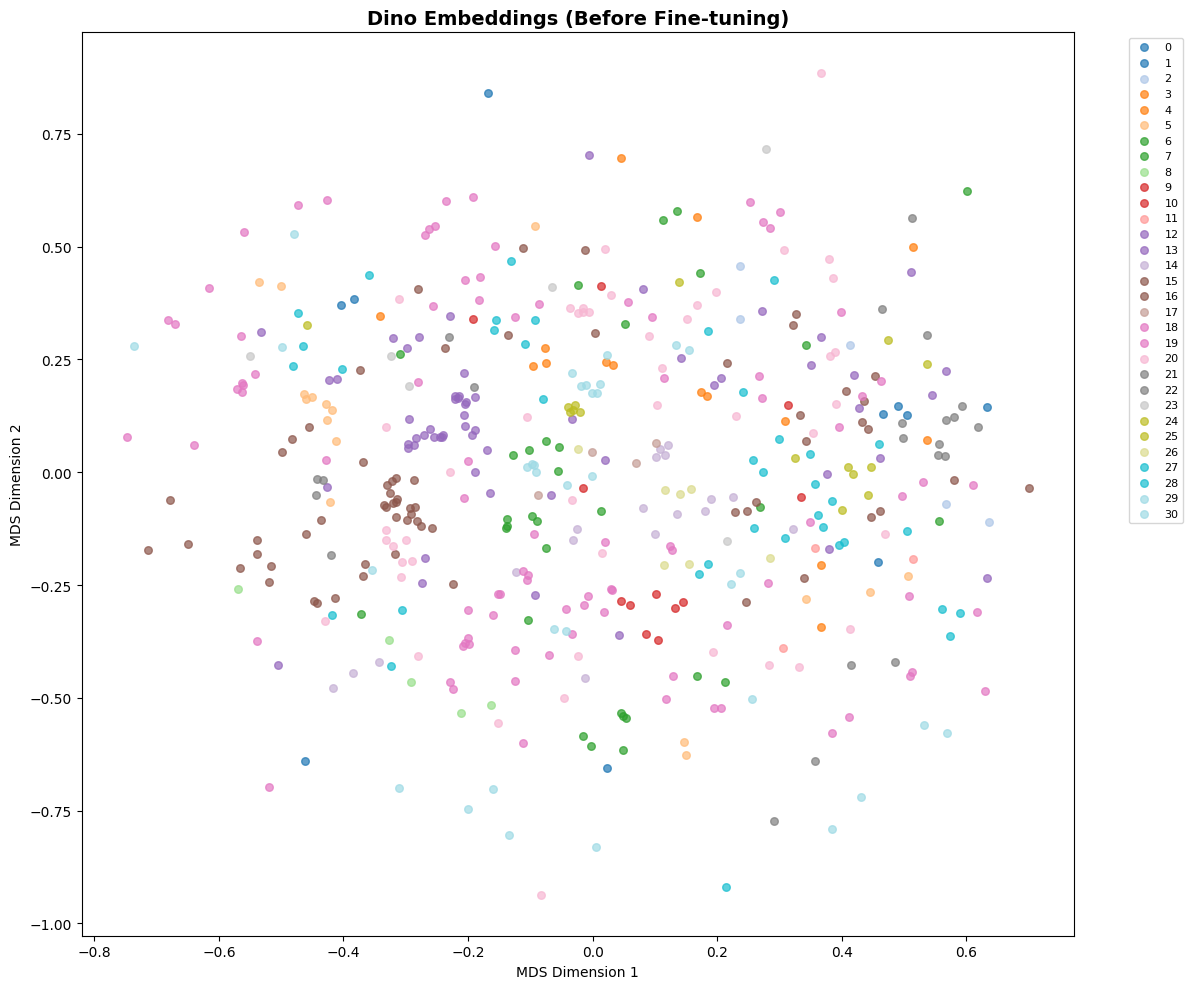

In [50]:
# Visualize Dino embeddings
fig = visualize_embeddings_mds(
    dino_embeddings,
    labels,
    "Dino Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "dino_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"dino_embeddings_mds": wandb.Image(fig)})

In [51]:
dino_emb_train_dataset = EmbeddingDataset(
    dino_embeddings[train_mask],
    train_labels
)

dino_emb_val_dataset = EmbeddingDataset(
    dino_embeddings[~train_mask],
    val_labels
)

dino_emb_train_loader = create_deterministic_training_dataloader(
    dino_emb_train_dataset,
    batch_size=config["batch_size"],
)
dino_emb_val_loader = DataLoader(
    dino_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=2,
    shuffle=False
)

In [52]:
# Create model
model = ArcFaceModel(
    input_dim=dino_dim,
    num_classes=num_classes,
    embedding_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    margin=config["arcface_margin"],
    dropout=config["dropout"],
).to(device)

model_num_params = sum(p.numel() for p in model.parameters())

print(f"  Total parameters: {model_num_params:,}")

  Total parameters: 534,528


In [53]:
# Setup training components
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: CrossEntropyLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [54]:
# Training loop
set_seeds(config['seed'])
history, best_val_loss, best_map_duplicated, best_epoch = train(
    model, 
    dino_emb_train_loader, 
    dino_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="dino"
)

wandb.log({
    "final_val_loss_dino": best_val_loss,
    "final_val_mAP_dino": best_map_duplicated,
    "best_epoch_dino": best_epoch,
    "total_epochs_dino": len(history['train_loss']),
})

table.append([
    "Dino",
    best_val_loss,
    best_map_duplicated,
    best_epoch,
    dino_num_params,
    model_num_params,
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/48 [00:00<?, ?it/s, loss=36.0225, acc=0.0%]

  Train Loss: 36.9159 | Train Acc: 0.0%
  Val Loss:   32.2316 | Val Acc:   0.0%
  Val mAP:    0.3505 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 31.9428 | Train Acc: 0.0%
  Val Loss:   27.2518 | Val Acc:   0.0%
  Val mAP:    0.3705 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 28.3171 | Train Acc: 0.0%
  Val Loss:   23.5563 | Val Acc:   4.5%
  Val mAP:    0.3965 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 0.2621 | Train Acc: 93.9%
  Val Loss:   3.1143 | Val Acc:   89.2%
  Val mAP:    0.8566 | LR: 2.50e-05
  No improvement. Patience: 6/10

Epoch 93/200


  Train Loss: 0.1996 | Train Acc: 95.4%
  Val Loss:   3.0770 | Val Acc:   89.7%
  Val mAP:    0.8612 | LR: 2.50e-05
  No improvement. Patience: 7/10

Epoch 94/200


  Train Loss: 0.2455 | Train Acc: 94.4%
  Val Loss:   3.0647 | Val Acc:   89.7%
  Val mAP:    0.8588 | LR: 2.50e-05
  No improvement. Patience: 8/10

Epoch 95/200


  Train Loss: 0.1887 | Train Acc: 95.5%
  Val Loss:   3.1198 | Val Acc:   89.2%
  Val mAP:    0.8561 | LR: 2.50e-05
  No improvement. Patience: 9/10

Epoch 96/200


  Train Loss: 0.2897 | Train Acc: 94.1%
  Val Loss:   3.0503 | Val Acc:   89.2%
  Val mAP:    0.8646 | LR: 2.50e-05
  No improvement. Patience: 10/10

Early stopping triggered after 96 epochs

Training complete!
Best epoch: 86 (Val Loss: 3.0478, Val mAP: 0.8578)


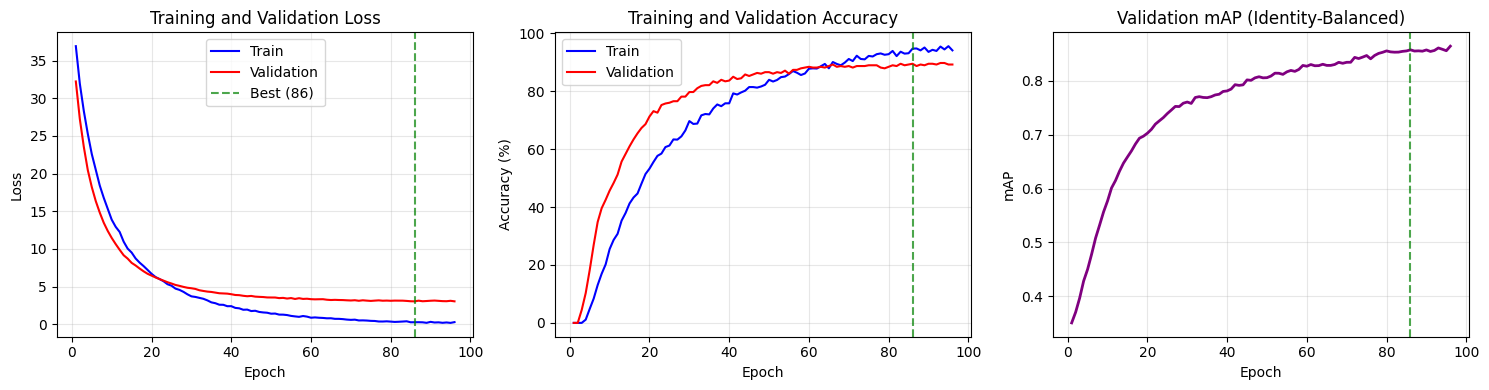

In [55]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_dino.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_dino": wandb.Image(fig)})

In [56]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "arcface_best_dino.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/backbone
  Val Loss: 3.0478
  Val mAP: 0.8578


In [57]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(dino_embeddings).to(device)
    finetuned_embeddings = model.get_embeddings(train_tensor).cpu().numpy()

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


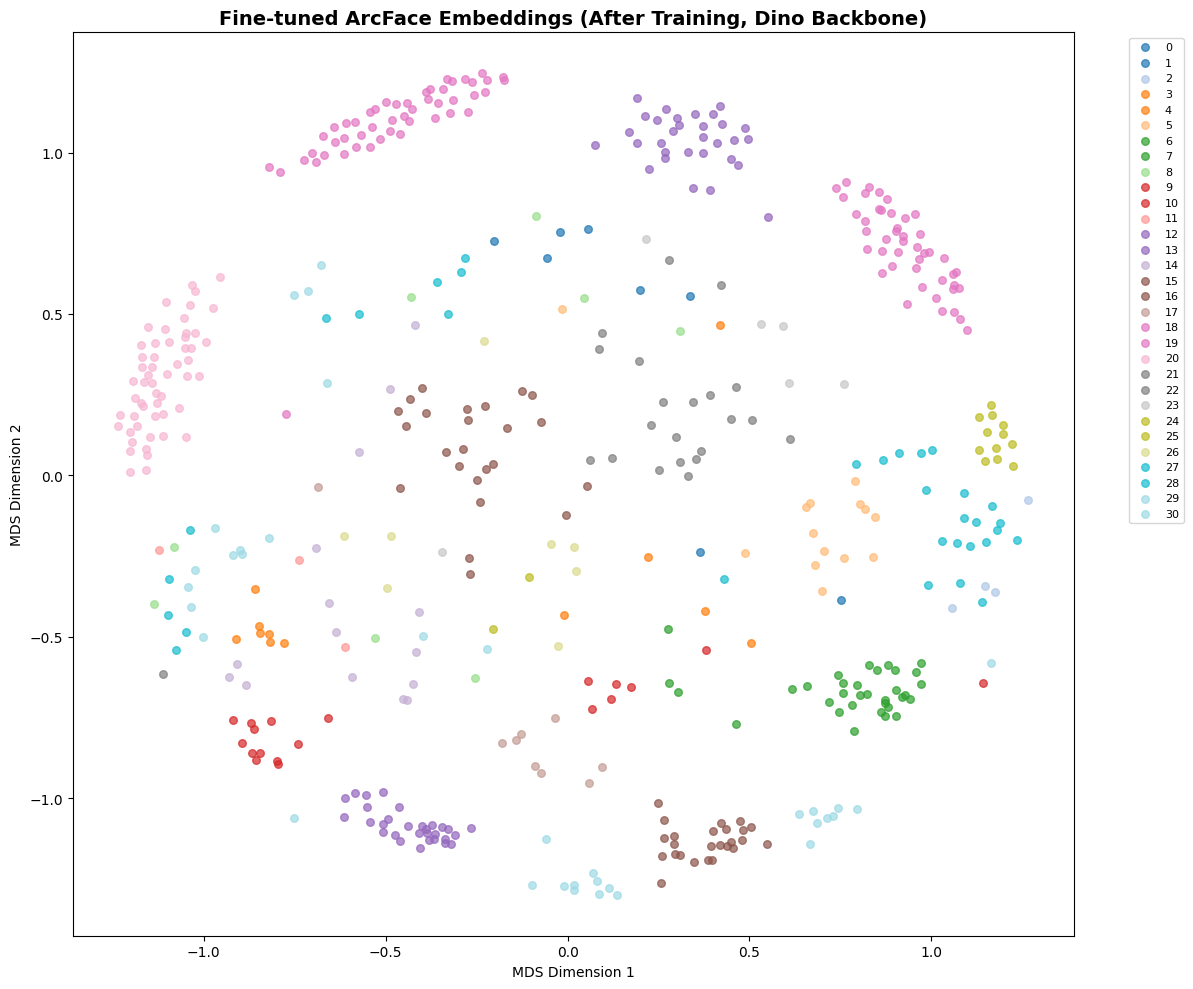

In [58]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ArcFace Embeddings (After Training, Dino Backbone)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "dino_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_dino": wandb.Image(fig_finetuned)})

In [59]:
del dino_dataset, dino_loader, dino_emb_train_dataset, dino_emb_val_dataset
del model, optimizer, scheduler, history
del dino, dino_preprocess, dino_embeddings, finetuned_embeddings
torch.cuda.empty_cache()

## EfficientNet

In [60]:
# Load EfficientNet model
print("Loading EfficientNet model...")
efficientnet = timm.create_model(
    config["efficientnet_model"],
    pretrained=True
)
efficientnet.eval()
efficientnet.to(device)
efficientnet.compile()

efficientnet_config = resolve_data_config({}, model=efficientnet)
efficientnet_preprocess = create_transform(**efficientnet_config, is_training=False)

efficientnet_num_params = sum(p.numel() for p in efficientnet.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {efficientnet_num_params:,}")
print(f"  Preprocessing: {efficientnet_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = efficientnet_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = efficientnet(dummy_input)
    efficientnet_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {efficientnet_dim}")

Loading EfficientNet model...
Model loaded successfully
  Parameters: 5,288,548
  Preprocessing: {'input_size': [3, 224, 224], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 0.875, 'crop_mode': 'center'}


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/torch/_inductor/compile_fx.py:312: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


  Embedding dimension: 1000


In [61]:
efficientnet_dataset = ImageDataset(image_paths, efficientnet_preprocess)
efficientnet_loader = DataLoader(
    efficientnet_dataset,
    batch_size=config["batch_size"],
    num_workers=2,
    shuffle=False
)

print(f"EfficientNet DataLoader created with {len(efficientnet_loader)} batches")

EfficientNet DataLoader created with 60 batches


In [62]:
efficientnet_cache_path = EMBEDDINGS_PATH / "efficientnet_embeddings.npz"

efficientnet_embeddings = get_embeddings(
    efficientnet,
    efficientnet_cache_path,
    efficientnet_loader
)

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/backbone/embeddings/efficientnet_embeddings.npz
Embeddings shape: (1895, 1000)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


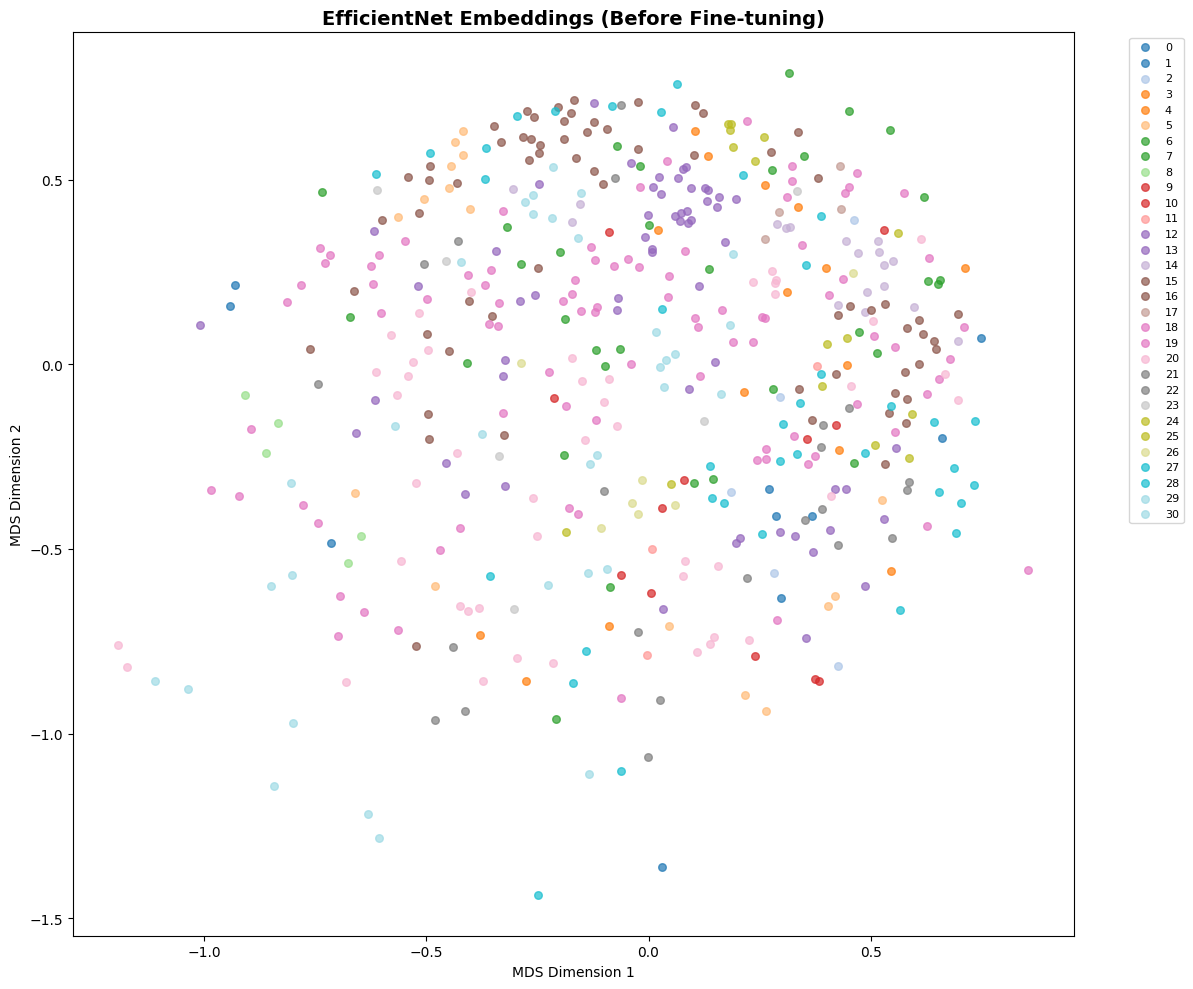

In [63]:
# Visualize EfficientNet embeddings
fig = visualize_embeddings_mds(
    efficientnet_embeddings,
    labels,
    "EfficientNet Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "efficientnet_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"efficientnet_embeddings_mds": wandb.Image(fig)})

In [64]:
efficientnet_emb_train_dataset = EmbeddingDataset(
    efficientnet_embeddings[train_mask],
    train_labels
)

efficientnet_emb_val_dataset = EmbeddingDataset(
    efficientnet_embeddings[~train_mask],
    val_labels
)

efficientnet_emb_train_loader = create_deterministic_training_dataloader(
    efficientnet_emb_train_dataset,
    batch_size=config["batch_size"],
)
efficientnet_emb_val_loader = DataLoader(
    efficientnet_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=2,
    shuffle=False
)

In [65]:
# Create model
model = ArcFaceModel(
    input_dim=efficientnet_dim,
    num_classes=num_classes,
    embedding_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    margin=config["arcface_margin"],
    dropout=config["dropout"],
).to(device)

model_num_params = sum(p.numel() for p in model.parameters())

print(f"  Total parameters: {model_num_params:,}")

  Total parameters: 653,312


In [66]:
# Setup training components
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: CrossEntropyLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [67]:
# Training loop
set_seeds(config['seed'])
history, best_val_loss, best_map, best_epoch = train(
    model, 
    efficientnet_emb_train_loader, 
    efficientnet_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="efficientnet"
)

wandb.log({
    "final_val_loss_efficientnet": best_val_loss,
    "final_val_mAP_efficientnet": best_map_duplicated,
    "best_epoch_efficientnet": best_epoch,
    "total_epochs_efficientnet": len(history['train_loss']),
})

table.append([
    "EfficientNet",
    best_val_loss,
    best_map,
    best_epoch,
    efficientnet_num_params,
    model_num_params,
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 37.2028 | Train Acc: 0.0%
  Val Loss:   33.6768 | Val Acc:   0.0%
  Val mAP:    0.3103 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 33.2474 | Train Acc: 0.0%
  Val Loss:   29.7952 | Val Acc:   0.0%
  Val mAP:    0.3234 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 30.1042 | Train Acc: 0.0%
  Val Loss:   26.7482 | Val Acc:   1.3%
  Val mAP:    0.3350 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 27.7247 | Train Acc: 0.4%
  Val Loss:   24.0004 | Val Acc:   5.8%
  Val mAP:    0.3536 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.4695 | Train Acc: 90.6%
  Val Loss:   4.5221 | Val Acc:   82.1%
  Val mAP:    0.7916 | LR: 2.50e-05
  No improvement. Patience: 6/10

Epoch 90/200


  Train Loss: 0.5499 | Train Acc: 90.0%
  Val Loss:   4.5360 | Val Acc:   81.5%
  Val mAP:    0.7912 | LR: 2.50e-05
  No improvement. Patience: 7/10

Epoch 91/200


  Train Loss: 0.4994 | Train Acc: 90.4%
  Val Loss:   4.5513 | Val Acc:   82.6%
  Val mAP:    0.7919 | LR: 2.50e-05
  No improvement. Patience: 8/10

Epoch 92/200


  Train Loss: 0.4979 | Train Acc: 90.8%
  Val Loss:   4.5082 | Val Acc:   82.3%
  Val mAP:    0.7880 | LR: 2.50e-05
  No improvement. Patience: 9/10

Epoch 93/200


  Train Loss: 0.3917 | Train Acc: 92.3%
  Val Loss:   4.6078 | Val Acc:   81.3%
  Val mAP:    0.7895 | LR: 2.50e-05
  No improvement. Patience: 10/10

Early stopping triggered after 93 epochs

Training complete!
Best epoch: 83 (Val Loss: 4.5025, Val mAP: 0.7921)


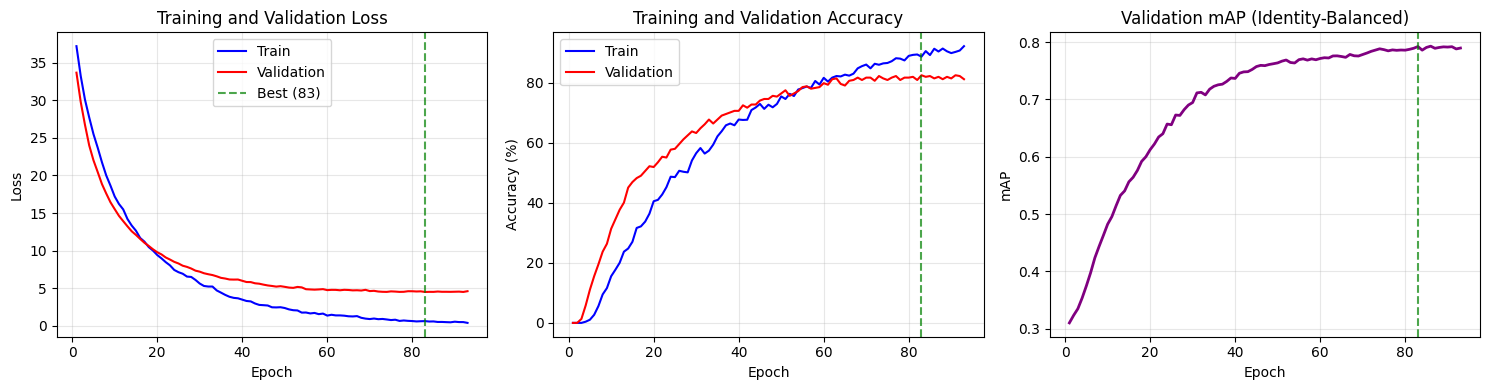

In [68]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_efficientnet.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_efficientnet": wandb.Image(fig)})

In [69]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "arcface_best_efficientnet.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/backbone
  Val Loss: 4.5025
  Val mAP: 0.7921


In [70]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(efficientnet_embeddings).to(device)
    finetuned_embeddings = model.get_embeddings(train_tensor).cpu().numpy()

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


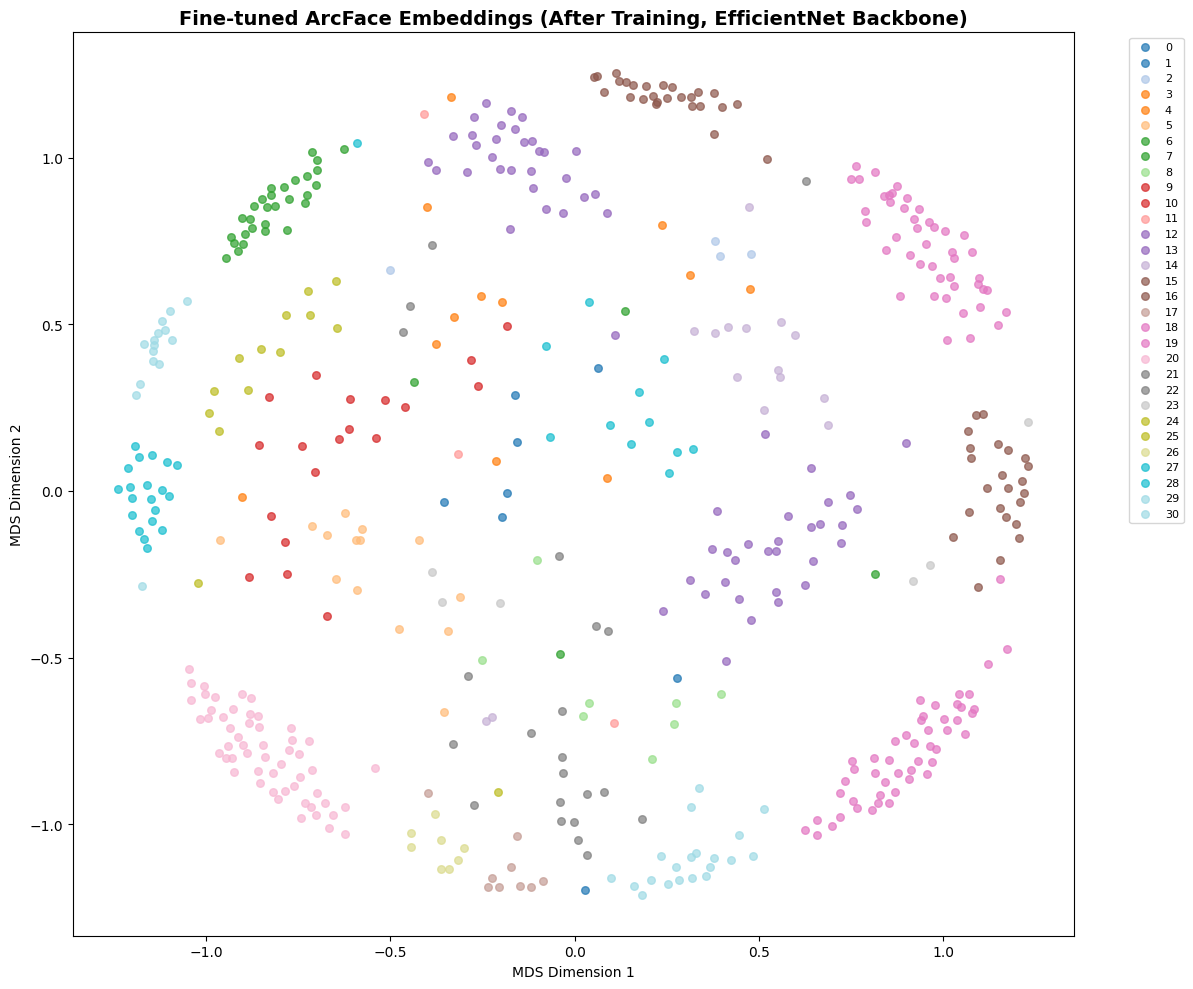

In [71]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ArcFace Embeddings (After Training, EfficientNet Backbone)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "efficientnet_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_efficientnet": wandb.Image(fig_finetuned)})

In [72]:
del efficientnet_dataset, efficientnet_loader, efficientnet_emb_train_dataset, efficientnet_emb_val_dataset
del model, optimizer, scheduler, history
del efficientnet, efficientnet_preprocess, efficientnet_embeddings, finetuned_embeddings
torch.cuda.empty_cache()

## ResNet18

In [73]:
# Load ResNet18 model
print("Loading ResNet18 model...")
resnet18 = timm.create_model(
    config["resnet18_model"],
    pretrained=True
)
resnet18.eval()
resnet18.to(device)
resnet18.compile()

resnet18_config = resolve_data_config({}, model=resnet18)
resnet18_preprocess = create_transform(**resnet18_config, is_training=False)

resnet18_num_params = sum(p.numel() for p in resnet18.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {resnet18_num_params:,}")
print(f"  Preprocessing: {resnet18_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = resnet18_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = resnet18(dummy_input)
    resnet18_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {resnet18_dim}")

Loading ResNet18 model...


Model loaded successfully
  Parameters: 11,689,512
  Preprocessing: {'input_size': [3, 224, 224], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 0.95, 'crop_mode': 'center'}
  Embedding dimension: 1000


In [74]:
resnet18_dataset = ImageDataset(image_paths, resnet18_preprocess)
resnet18_loader = DataLoader(
    resnet18_dataset,
    batch_size=config["batch_size"],
    num_workers=2,
    shuffle=False
)

print(f"ResNet18 DataLoader created with {len(resnet18_loader)} batches")

ResNet18 DataLoader created with 60 batches


In [75]:
resnet18_cache_path = EMBEDDINGS_PATH / "resnet18_embeddings.npz"

resnet18_embeddings = get_embeddings(
    resnet18,
    resnet18_cache_path,
    resnet18_loader
)

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/backbone/embeddings/resnet18_embeddings.npz
Embeddings shape: (1895, 1000)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


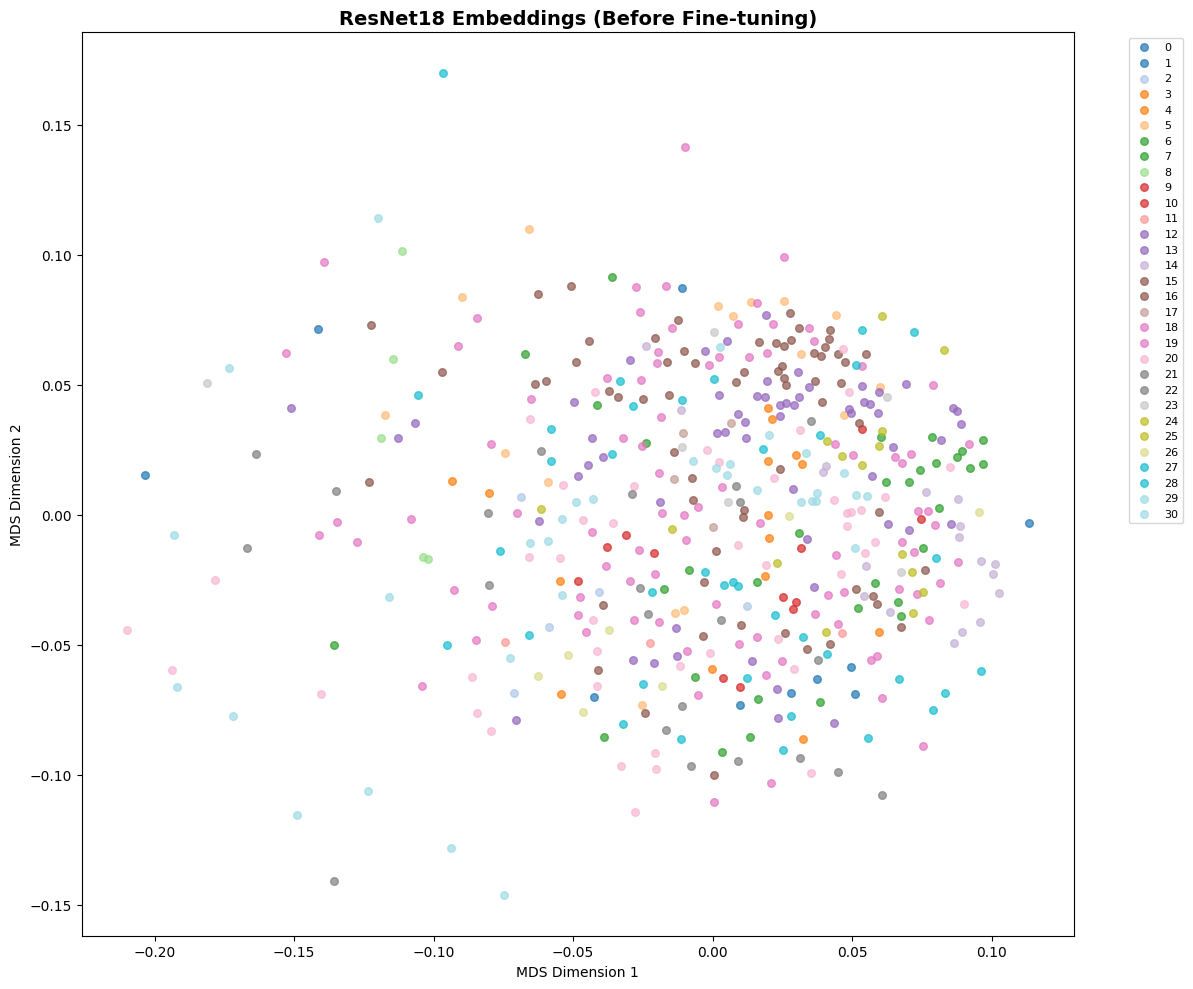

In [76]:
# Visualize ResNet18 embeddings
fig = visualize_embeddings_mds(
    resnet18_embeddings,
    labels,
    "ResNet18 Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "resnet18_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"resnet18_embeddings_mds": wandb.Image(fig)})

In [77]:
resnet18_emb_train_dataset = EmbeddingDataset(
    resnet18_embeddings[train_mask],
    train_labels
)

resnet18_emb_val_dataset = EmbeddingDataset(
    resnet18_embeddings[~train_mask],
    val_labels
)

resnet18_emb_train_loader = create_deterministic_training_dataloader(
    resnet18_emb_train_dataset,
    batch_size=config["batch_size"],
)
resnet18_emb_val_loader = DataLoader(
    resnet18_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=2,
    shuffle=False
)

In [78]:
# Create model
model = ArcFaceModel(
    input_dim=resnet18_dim,
    num_classes=num_classes,
    embedding_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    margin=config["arcface_margin"],
    dropout=config["dropout"],
).to(device)

model_num_params = sum(p.numel() for p in model.parameters())

print(f"  Total parameters: {model_num_params:,}")

  Total parameters: 653,312


In [79]:
# Setup training components
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: CrossEntropyLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [80]:
# Training loop
set_seeds(config['seed'])
history, best_val_loss, best_map, best_epoch = train(
    model, 
    resnet18_emb_train_loader, 
    resnet18_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="resnet18"
)

wandb.log({
    "final_val_loss_resnet18": best_val_loss,
    "final_val_mAP_resnet18": best_map_duplicated,
    "best_epoch_resnet18": best_epoch,
    "total_epochs_resnet18": len(history['train_loss']),
})

table.append([
    "ResNet18",
    best_val_loss,
    best_map,
    best_epoch,
    resnet18_num_params,
    model_num_params,
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/48 [00:00<?, ?it/s, loss=37.5955, acc=0.0%]

  Train Loss: 36.7487 | Train Acc: 0.0%
  Val Loss:   35.7496 | Val Acc:   0.0%
  Val mAP:    0.2103 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 33.7341 | Train Acc: 0.0%
  Val Loss:   34.2684 | Val Acc:   0.0%
  Val mAP:    0.2137 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 31.7455 | Train Acc: 0.0%
  Val Loss:   31.1424 | Val Acc:   0.0%
  Val mAP:    0.2274 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 5.5786 | Train Acc: 56.1%
  Val Loss:   8.6721 | Val Acc:   59.1%
  Val mAP:    0.6352 | LR: 7.81e-07
  No improvement. Patience: 6/10

Epoch 152/200


  Train Loss: 5.7257 | Train Acc: 55.2%
  Val Loss:   8.7316 | Val Acc:   59.4%
  Val mAP:    0.6324 | LR: 7.81e-07
  No improvement. Patience: 7/10

Epoch 153/200


  Train Loss: 5.4899 | Train Acc: 56.5%
  Val Loss:   8.7248 | Val Acc:   59.6%
  Val mAP:    0.6410 | LR: 7.81e-07
  No improvement. Patience: 8/10

Epoch 154/200


  Train Loss: 5.3761 | Train Acc: 56.9%
  Val Loss:   8.7283 | Val Acc:   59.9%
  Val mAP:    0.6327 | LR: 7.81e-07
  No improvement. Patience: 9/10

Epoch 155/200


  Train Loss: 5.4831 | Train Acc: 55.8%
  Val Loss:   8.6767 | Val Acc:   59.6%
  Val mAP:    0.6372 | LR: 7.81e-07
  No improvement. Patience: 10/10

Early stopping triggered after 155 epochs

Training complete!
Best epoch: 145 (Val Loss: 8.6697, Val mAP: 0.6399)


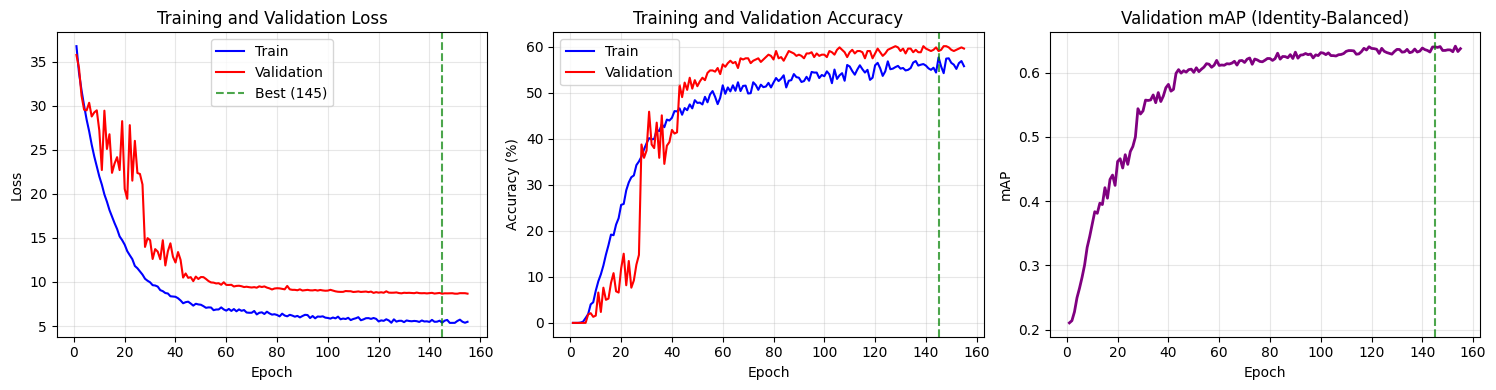

In [81]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_resnet18.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_resnet18": wandb.Image(fig)})

In [82]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "arcface_best_resnet18.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/backbone
  Val Loss: 8.6697
  Val mAP: 0.6399


In [83]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(resnet18_embeddings).to(device)
    finetuned_embeddings = model.get_embeddings(train_tensor).cpu().numpy()

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


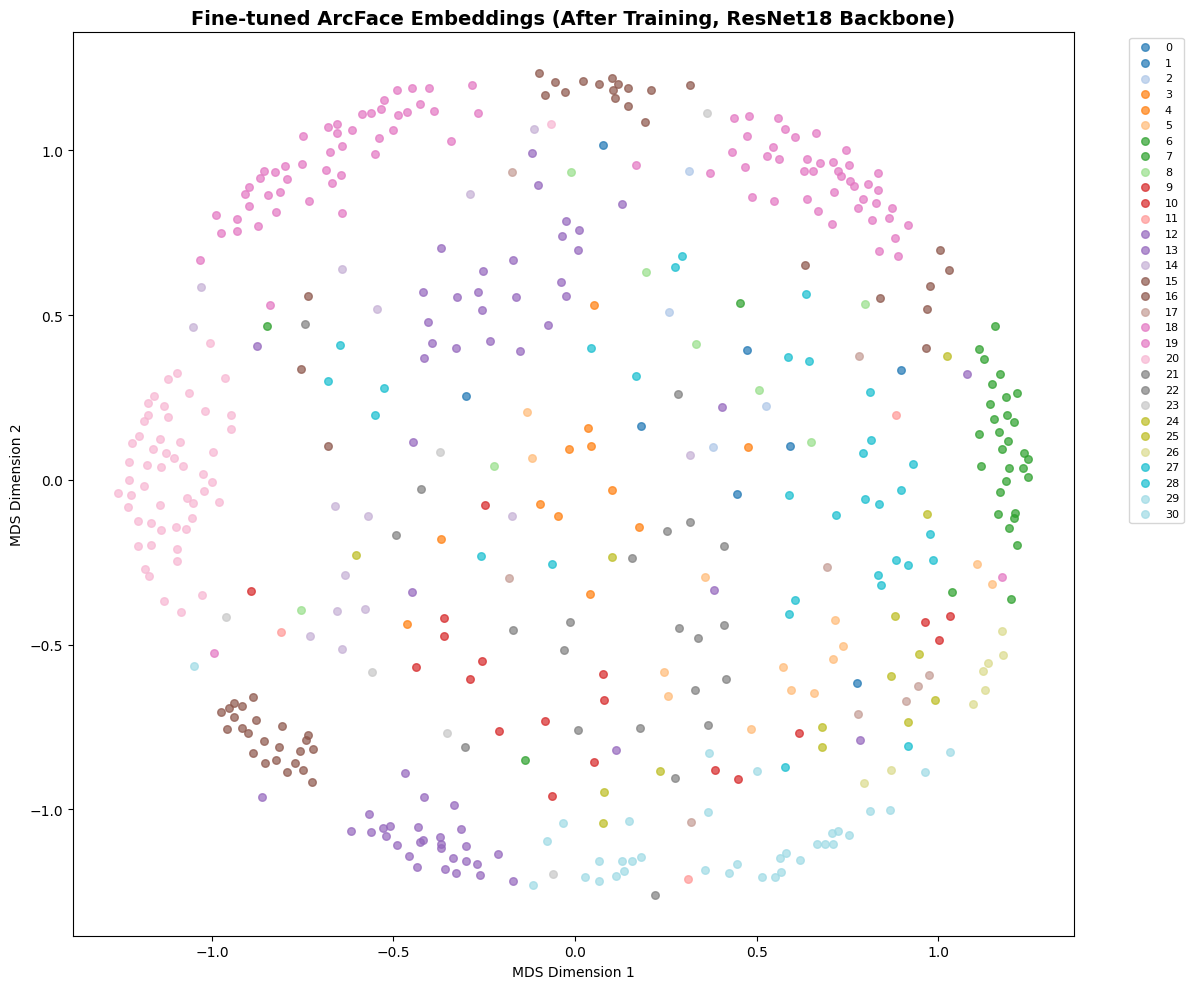

In [84]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ArcFace Embeddings (After Training, ResNet18 Backbone)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "resnet18_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_resnet18": wandb.Image(fig_finetuned)})

In [85]:
del resnet18_dataset, resnet18_loader, resnet18_emb_train_dataset, resnet18_emb_val_dataset
del model, optimizer, scheduler, history
del resnet18, resnet18_preprocess, resnet18_embeddings, finetuned_embeddings
torch.cuda.empty_cache()

## Summary

In [86]:
rows = list(zip(*table)) # transpose for tabulate
print(tabulate(rows[1:], headers=rows[0], tablefmt="grid"))

+----------------+------------------+------------------+------------------+------------------+------------------+
| Backbone       |   MegaDescriptor |             CLIP |             Dino |     EfficientNet |         ResNet18 |
+================+==================+==================+==================+==================+==================+
| Best val_loss  |      4.59358     |      4.71094     |      3.04782     |      4.50245     |      8.66971     |
+----------------+------------------+------------------+------------------+------------------+------------------+
| Best val_mAP   |      0.787877    |      0.826058    |      0.857793    |      0.792118    |      0.639875    |
+----------------+------------------+------------------+------------------+------------------+------------------+
| Best epoch     |     72           |    135           |     86           |     83           |    145           |
+----------------+------------------+------------------+------------------+-------------

## Submission

In [ ]:
embedding_model = timm.create_model(
    config["dinov3_model"],
    pretrained=True
)
embedding_model.eval()
embedding_model.to(device)
embedding_model.compile()

embedding_config = resolve_data_config({}, model=embedding_model)
embedding_preprocess = create_transform(**embedding_config, is_training=False)

print(f"Embedding model: {config['dinov3_model']}")
print(f"  Parameters: {sum(p.numel() for p in embedding_model.parameters()):,}")
print(f"  Preprocessing: {embedding_config}")

In [ ]:
arc_face_model = ArcFaceModel(
    input_dim=dino_dim,
    num_classes=num_classes,
    embedding_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    margin=config["arcface_margin"],
    dropout=config["dropout"],
).to(device)

checkpoint = torch.load(CHECKPOINT_PATH / "arcface_best_dino.pth", map_location=device, weights_only=False)
arc_face_model.load_state_dict(checkpoint['model_state_dict'])
arc_face_model.eval()

In [ ]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(DATA_PATH / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

In [ ]:
# Get unique test images
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [DATA_PATH / "test" / filename for filename in test_images]

# Extract embeddings for test images
print(f"\nExtracting embeddings for test images...")
test_embeddings = extract_embeddings(
    embedding_model,
    test_image_paths,
    batch_size=config["batch_size"],
    desc="Test embeddings"
)

print(f"Test embeddings shape: {test_embeddings.shape}")

In [ ]:
# Project through fine-tuned model
arc_face_model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_embeddings).to(device)
    test_finetuned_embeddings = arc_face_model.get_embeddings(test_tensor).cpu().numpy()

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(test_finetuned_embeddings, axis=1).mean():.4f}")

# Create mapping from filename to embedding
img_to_embedding = {
    filename: embedding 
    for filename, embedding in zip(test_images, test_finetuned_embeddings)
}

In [ ]:
# Compute similarity for each pair
print("Computing pairwise similarities...")
similarities = []

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    
    # Cosine similarity (embeddings are already normalized)
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

# Clip to [0, 1] range
similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

In [ ]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(DATA_PATH / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

In [ ]:
# Save submission
submission_path = OUTPUT_PATH / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")